In [11]:
from keras.layers import Dense,Dropout, BatchNormalization,Flatten
from keras.models import load_model,save_model
from keras.models import Model
from keras.applications.vgg19 import VGG19
from keras.applications.vgg16 import preprocess_input
from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
train_path = '/datasets/train'
valid_path = '/datasets/test'

In [13]:
# load model without output layer

IMAGE_SIZE = [224, 224]
# add preprocessing layer to the front of VGG
vgg = VGG19(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [14]:
# don't train existing weights
for layer in vgg.layers:
    layer.trainable = False

In [16]:
x = Flatten()(vgg.output)
# x = Dense(1000, activation='relu')(x)
prediction = Dense(len(folders), activation='softmax')(x)

In [17]:
# create a model object
model = Model(inputs=vgg.input, outputs=prediction)

In [18]:
# view the structure of the model
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0   

In [19]:
# tell the model what cost and optimization method to use
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [ ]:
from keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

val_datagen = ImageDataGenerator(rescale = 1./255)

training_set = train_datagen.flow_from_directory('/datasets/train',
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

val_set = val_datagen.flow_from_directory('/datasets/test',
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical')

# fit the model
history = model.fit_generator(training_set,
                              validation_data=val_set,
                              epochs=20,
                              steps_per_epoch=len(training_set),
                              validation_steps=len(val_set))


Found 120 images belonging to 2 classes.


Found 120 images belonging to 2 classes.


C:\Users\vishw\AppData\Local\Temp\ipykernel_5136\4135273838.py:20: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(training_set,


Epoch 1/20
4/4 [==============================] - 32s 9s/step - loss: 1.8640 - accuracy: 0.4583 - val_loss: 1.7071 - val_accuracy: 0.5000
Epoch 2/20
4/4 [==============================] - 34s 10s/step - loss: 1.0039 - accuracy: 0.6250 - val_loss: 0.8512 - val_accuracy: 0.5333
Epoch 3/20
4/4 [==============================] - 37s 11s/step - loss: 0.5966 - accuracy: 0.6833 - val_loss: 0.3180 - val_accuracy: 0.8500
Epoch 4/20
4/4 [==============================] - 34s 10s/step - loss: 0.4969 - accuracy: 0.8083 - val_loss: 0.2616 - val_accuracy: 0.8917
Epoch 5/20
4/4 [==============================] - 37s 11s/step - loss: 0.2118 - accuracy: 0.9000 - val_loss: 0.2605 - val_accuracy: 0.8417
Epoch 6/20
4/4 [==============================] - 33s 10s/step - loss: 0.2212 - accuracy: 0.9250 - val_loss: 0.1417 - val_accuracy: 0.9417
Epoch 7/20
4/4 [==============================] - 34s 9s/step - loss: 0.2005 - accuracy: 0.9000 - val_loss: 0.1068 - val_accuracy: 0.9667
Epoch 8/20
4/4 [=============

        loss  accuracy  val_loss  val_accuracy
0   1.863950  0.458333  1.707091      0.500000
1   1.003853  0.625000  0.851178      0.533333
2   0.596644  0.683333  0.318024      0.850000
3   0.496860  0.808333  0.261553      0.891667
4   0.211755  0.900000  0.260456      0.841667
5   0.221185  0.925000  0.141673      0.941667
6   0.200546  0.900000  0.106818      0.966667
7   0.100593  0.983333  0.076215      0.983333
8   0.095830  0.991667  0.061448      0.991667
9   0.089931  0.975000  0.060956      0.991667
10  0.072839  0.983333  0.045919      0.991667
11  0.063621  1.000000  0.040762      1.000000
12  0.057039  0.991667  0.040514      0.991667
13  0.038920  1.000000  0.034044      1.000000
14  0.036154  1.000000  0.028454      1.000000
15  0.032615  1.000000  0.026344      1.000000
16  0.042805  0.991667  0.024059      1.000000
17  0.028938  1.000000  0.024879      1.000000
18  0.035139  1.000000  0.021526      1.000000
19  0.027796  1.000000  0.021384      1.000000


<AxesSubplot:>

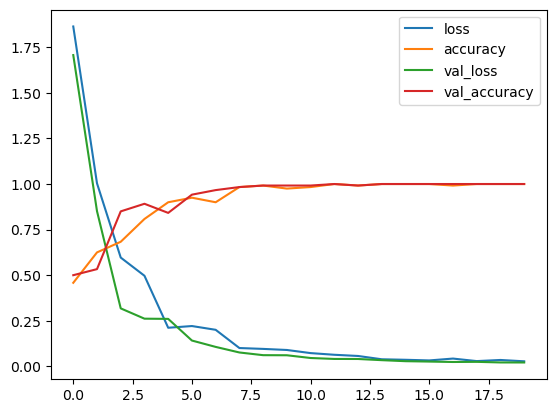

In [21]:
from keras.models import load_model

model.save('model.h5')


print(pd.DataFrame(history.history))

pd.DataFrame(history.history).plot()

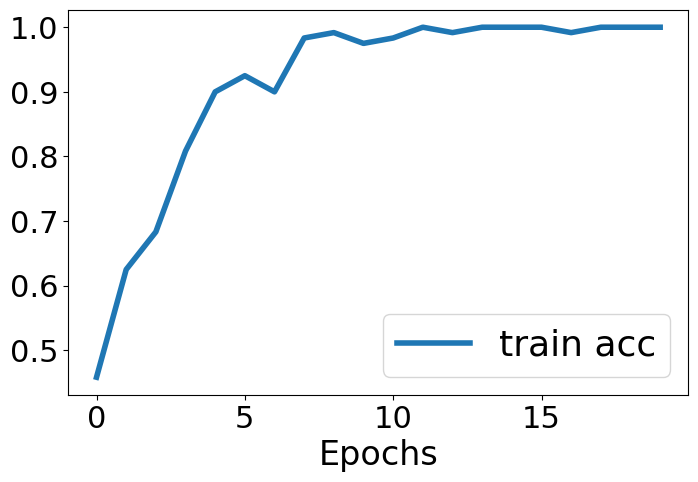

In [22]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots( figsize = (8,5))
ax.plot(history.history['accuracy'], label= 'train acc', linewidth = 4)
ax.legend(fontsize = 26)
ax.tick_params(labelsize=22)
ax.set_xlabel('Epochs', fontsize = 24)


plt.show()


4/4 [==============================] - 17s 4s/step


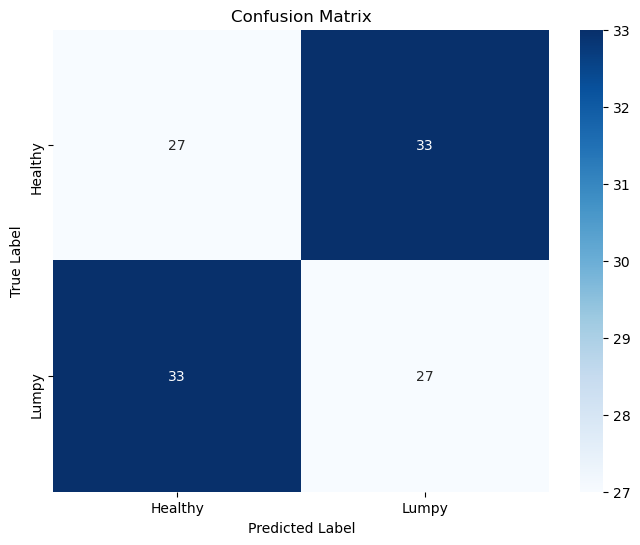

Classification Report:

              precision    recall  f1-score   support

     Healthy       0.45      0.45      0.45        60
       Lumpy       0.45      0.45      0.45        60

    accuracy                           0.45       120
   macro avg       0.45      0.45      0.45       120
weighted avg       0.45      0.45      0.45       120



In [23]:
# %%
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get the class indices mapping
class_labels = list(training_set.class_indices.keys())

# Predict on validation/test set
Y_pred = model.predict(val_set)
y_pred = np.argmax(Y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(val_set.classes, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(val_set.classes, y_pred, target_names=class_labels))
